# CPG Product Intelligence - Report

* Data Extraction Date: July 22nd, 2026
* Source Dataset: Open Food Facts (Crowdsourced Open Dataset)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Importing Datasets
cocacola = pd.read_csv(r'datasets\coca-cola_from_dump.csv')
fairlife = pd.read_csv(r'datasets\fairlife_from_dump.csv')
fanta = pd.read_csv(r'datasets\fanta_from_dump.csv')
maaza = pd.read_csv(r'datasets\maaza_from_dump.csv')
minutemaid = pd.read_csv(r'datasets\minute maid_from_dump.csv')
schweppes = pd.read_csv(r'datasets\schweppes_from_dump.csv')
sprite = pd.read_csv(r'datasets\sprite_from_dump.csv')
topochico = pd.read_csv(r'datasets\topo chico_from_dump.csv')

## Section 1: Global Overview

In [3]:
def prepare_brand_data(df):
    """
    Creates cleaned copies for:
    - country analysis
    - packaging analysis
    - general analysis

    Works with datasets containing:
    countries_tags
    packaging_tags
    code
    """

    df = df.copy()

    # -------------------------
    # Standardize text columns
    # -------------------------

    for col in [
        "countries_tags",
        "packaging_tags",
        "nutriscore_grade",
        "ecoscore_grade"
    ]:

        if col in df.columns:
            df[col] = (
                df[col]
                .fillna("")
                .astype(str)
                .str.strip()
                .str.lower()
            )

    # -------------------------
    # Country Data
    # -------------------------

    if "countries_tags" in df.columns:

        country_df = df.copy()

        country_df["countries_tags"] = (
            country_df["countries_tags"]
            .str.split(",")
        )

        country_df = country_df.explode("countries_tags")

        country_df["countries_tags"] = (
            country_df["countries_tags"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        country_df = country_df[
            country_df["countries_tags"].notna()
            & (country_df["countries_tags"] != "")
            & (country_df["countries_tags"] != "unknown")
            & (country_df["countries_tags"] != "nan")
        ]

    else:
        country_df = pd.DataFrame()

    # -------------------------
    # Packaging Data
    # -------------------------

    if "packaging_tags" in df.columns:

        pack_df = df.copy()

        pack_df["packaging_tags"] = (
            pack_df["packaging_tags"]
            .str.split(",")
        )

        pack_df = pack_df.explode("packaging_tags")

        pack_df["packaging_tags"] = (
            pack_df["packaging_tags"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        pack_df.loc[
            pack_df["packaging_tags"].isin(
                ["", "nan", "none"]
            ),
            "packaging_tags"
        ] = "unknown"

    else:
        pack_df = pd.DataFrame()

    return df, country_df, pack_df

### Brand: Coca-Cola

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Fairlife

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Fanta

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Maaza

In [4]:
brand_name = "maaza"

df, country_df, pack_df = prepare_brand_data(
    maaza
)

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

In [5]:
def plot_top_markets(
    country_df,
    brand_name,
    product_col="code",
    country_col="countries_tags",
    top_n=10
):

    if country_df.empty:
        print("Country data is not available.")
        return

    if product_col not in country_df.columns:
        print(f"Column '{product_col}' not found.")
        return

    # Count unique products
    country_counts = (
        country_df
        .groupby(country_col)[product_col]
        .nunique()
        .sort_values(ascending=False)
        .head(top_n)
    )

    # Plot
    plt.figure(figsize=(10, 6))

    country_counts.sort_values().plot(
        kind="barh"
    )

    plt.title(
        f"Top {top_n} Markets by Product Representation — {brand_name}"
    )

    plt.xlabel("Number of Unique Products")
    plt.ylabel("Country")

    plt.tight_layout()
    plt.show()

    # -------------------------
    # Automatic Observation
    # -------------------------

    top_country = country_counts.index[0]
    top_value = country_counts.iloc[0]

    observation = (
        f"Observation: {top_country.title()} has the highest "
        f"product representation with {top_value:,} unique products."
    )

    if len(country_counts) >= 3:

        second_country = country_counts.index[1]
        second_value = country_counts.iloc[1]

        third_country = country_counts.index[2]
        third_value = country_counts.iloc[2]

        observation += (
            f" It is followed by {second_country.title()} "
            f"with {second_value:,} products and "
            f"{third_country.title()} with {third_value:,} products."
        )

    observation += (
        " This indicates that the dataset is geographically "
        "concentrated in a limited number of major markets."
    )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

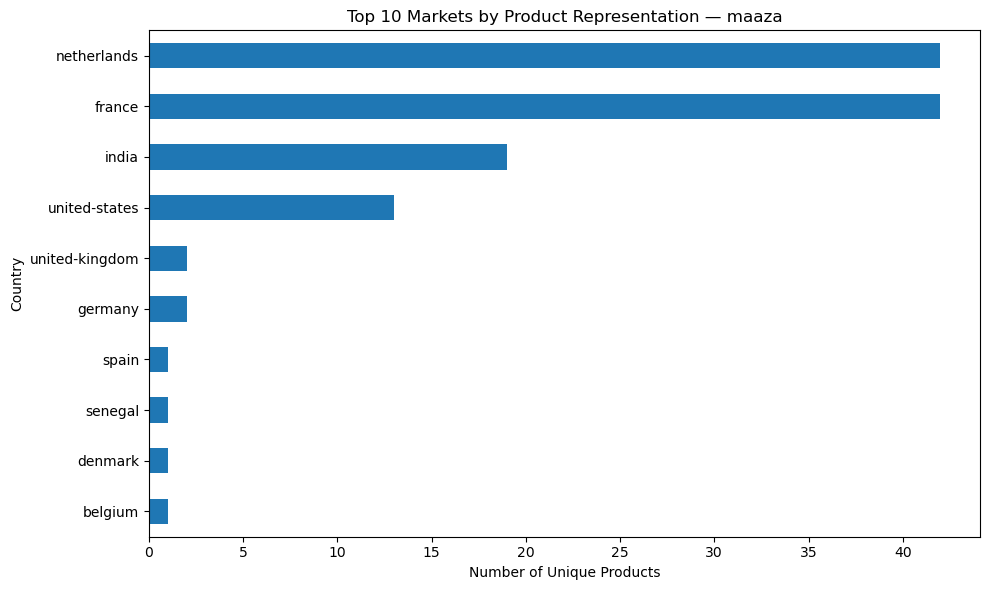


Observation: France has the highest product representation with 42 unique products. It is followed by Netherlands with 42 products and India with 19 products. This indicates that the dataset is geographically concentrated in a limited number of major markets.


In [6]:
plot_top_markets(
    country_df,
    brand_name
)

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

In [7]:
def plot_market_density(
    country_df,
    brand_name,
    product_col="code",
    country_col="countries_tags",
    top_n=8
):

    if country_df.empty:
        print("Country data is not available.")
        return

    market_counts = (
        country_df
        .groupby(country_col)[product_col]
        .nunique()
        .sort_values(ascending=False)
        .head(top_n)
    )

    total = market_counts.sum()

    market_percentage = (
        market_counts / total * 100
    )

    # Plot
    plt.figure(figsize=(8, 8))

    plt.pie(
        market_counts,
        labels=[
            country.title()
            for country in market_counts.index
        ],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"width": 0.45}
    )

    plt.title(
        f"Market Density Distribution — {brand_name}"
    )

    plt.tight_layout()
    plt.show()

    # Automatic observation

    top_market = market_counts.index[0]
    top_percentage = market_percentage.iloc[0]

    top_three_percentage = (
        market_percentage
        .head(3)
        .sum()
    )

    observation = (
        f"Observation: {top_market.title()} represents the "
        f"largest share of products among the top {top_n} markets "
        f"at {top_percentage:.1f}%."
    )

    observation += (
        f" The top three markets together account for "
        f"{top_three_percentage:.1f}% of the products represented "
        f"in this visualization, indicating that the portfolio "
        f"is concentrated in a relatively small number of markets."
    )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

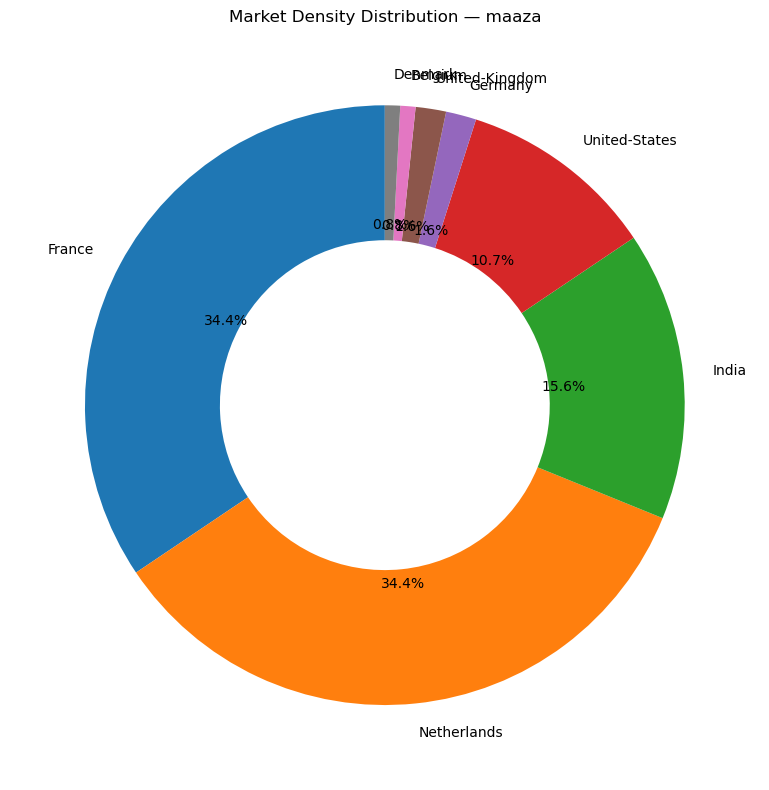


Observation: France represents the largest share of products among the top 8 markets at 34.4%. The top three markets together account for 84.4% of the products represented in this visualization, indicating that the portfolio is concentrated in a relatively small number of markets.


In [8]:
plot_market_density(
    country_df,
    brand_name
)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

In [9]:
def plot_portfolio_distribution(
    country_df,
    brand_name,
    product_col="code",
    country_col="countries_tags"
):

    if country_df.empty:
        print("Country data is not available.")
        return

    # Number of markets per product
    product_markets = (
        country_df
        .groupby(product_col)[country_col]
        .nunique()
    )

    # Classification
    portfolio_type = product_markets.apply(
        lambda x:
        "Localized"
        if x == 1
        else "Multi-Market"
    )

    portfolio_counts = (
        portfolio_type
        .value_counts()
    )

    total = portfolio_counts.sum()

    percentages = (
        portfolio_counts / total * 100
    )

    # Plot
    plt.figure(figsize=(7, 5))

    portfolio_counts.plot(
        kind="bar"
    )

    plt.title(
        f"Localized vs Multi-Market Products — {brand_name}"
    )

    plt.xlabel("Portfolio Type")
    plt.ylabel("Number of Unique Products")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # Automatic observation

    dominant = portfolio_counts.idxmax()
    dominant_count = portfolio_counts.max()
    dominant_percentage = percentages[dominant]

    observation = (
        f"Observation: {dominant} products represent the larger "
        f"segment of the portfolio, accounting for "
        f"{dominant_percentage:.1f}% ({dominant_count:,} products)."
    )

    if dominant == "Localized":

        observation += (
            " This suggests that the dataset contains a stronger "
            "presence of products associated with individual markets, "
            "indicating localized portfolio representation."
        )

    else:

        observation += (
            " This suggests that a substantial portion of products "
            "are associated with multiple markets, indicating "
            "broader international distribution."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

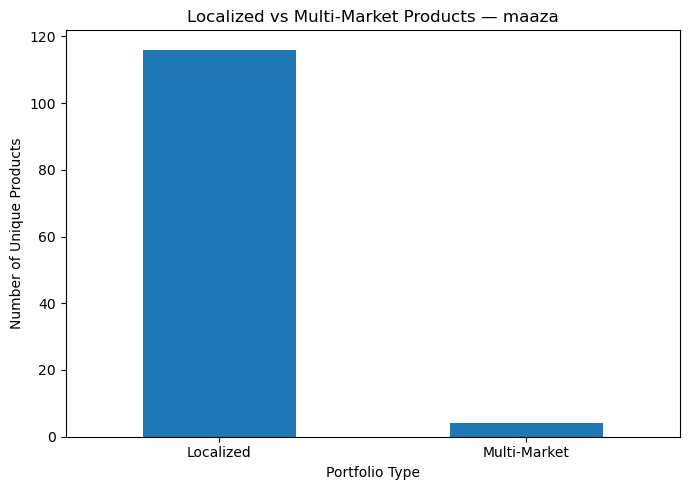


Observation: Localized products represent the larger segment of the portfolio, accounting for 96.7% (116 products). This suggests that the dataset contains a stronger presence of products associated with individual markets, indicating localized portfolio representation.


In [10]:
plot_portfolio_distribution(
    country_df,
    brand_name
)

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

In [11]:
def plot_sugar_distribution(
    df,
    brand_name,
    sugar_col="nutriments.sugars_100g"
):

    if sugar_col not in df.columns:

        print(
            f"Sugar column '{sugar_col}' not found."
        )

        return

    sugar = pd.to_numeric(
        df[sugar_col],
        errors="coerce"
    ).dropna()

    if sugar.empty:

        print("No valid sugar data available.")
        return

    # Plot

    plt.figure(figsize=(10, 5))

    plt.hist(
        sugar,
        bins=25
    )

    plt.title(
        f"Sugar Content Distribution — {brand_name}"
    )

    plt.xlabel("Sugar (g/100g)")
    plt.ylabel("Number of Products")

    plt.tight_layout()
    plt.show()

    # Statistics

    median = sugar.median()
    mean = sugar.mean()
    minimum = sugar.min()
    maximum = sugar.max()

    q1 = sugar.quantile(0.25)
    q3 = sugar.quantile(0.75)

    observation = (
        f"Observation: Sugar content ranges from "
        f"{minimum:.1f} to {maximum:.1f} g/100g, "
        f"with a median of {median:.1f} g/100g."
    )

    observation += (
        f" The middle 50% of products fall between "
        f"{q1:.1f} and {q3:.1f} g/100g."
    )

    # Detect skew

    if mean > median * 1.2:

        observation += (
            " The mean is noticeably higher than the median, "
            "suggesting that a smaller number of high-sugar products "
            "are pulling the overall average upward."
        )

    elif median > mean * 1.2:

        observation += (
            " The median is noticeably higher than the mean, "
            "indicating that lower-value products may be influencing "
            "the overall average."
        )

    else:

        observation += (
            " The mean and median are relatively close, suggesting "
            "that the overall distribution is not strongly skewed."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

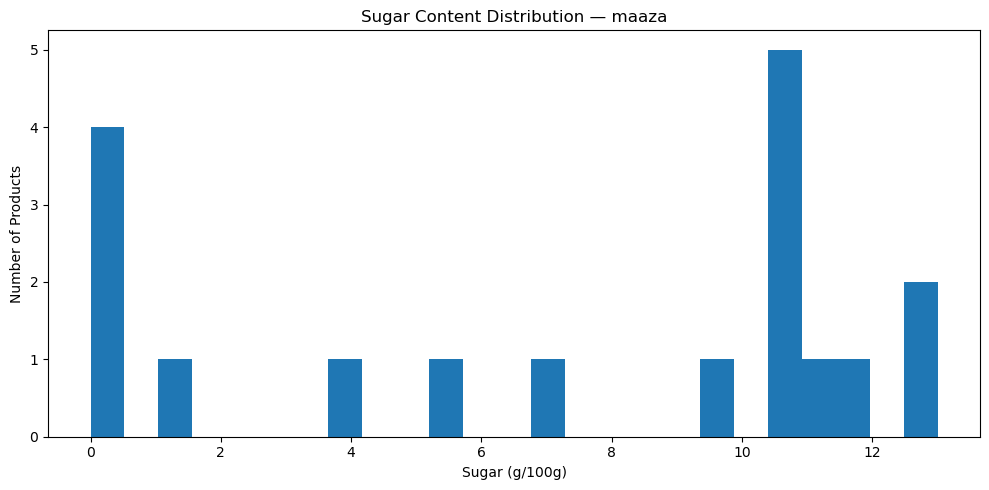


Observation: Sugar content ranges from 0.0 to 13.0 g/100g, with a median of 10.0 g/100g. The middle 50% of products fall between 2.0 and 10.9 g/100g. The median is noticeably higher than the mean, indicating that lower-value products may be influencing the overall average.


In [12]:
plot_sugar_distribution(
    df,
    brand_name
)

##### Caloric Density

In [13]:
def plot_calorie_distribution(
    df,
    brand_name,
    calorie_col="nutriments.energy-kcal_100g"
):

    if calorie_col not in df.columns:

        print(
            f"Calorie column '{calorie_col}' not found."
        )

        return

    calories = pd.to_numeric(
        df[calorie_col],
        errors="coerce"
    ).dropna()

    if calories.empty:

        print("No valid calorie data available.")
        return

    # Plot

    plt.figure(figsize=(10, 5))

    plt.hist(
        calories,
        bins=25
    )

    plt.title(
        f"Caloric Density Distribution — {brand_name}"
    )

    plt.xlabel("Energy (kcal/100g)")
    plt.ylabel("Number of Products")

    plt.tight_layout()
    plt.show()

    # Statistics

    median = calories.median()
    mean = calories.mean()

    minimum = calories.min()
    maximum = calories.max()

    q1 = calories.quantile(0.25)
    q3 = calories.quantile(0.75)

    observation = (
        f"Observation: Energy content ranges from "
        f"{minimum:.1f} to {maximum:.1f} kcal/100g, "
        f"with a median of {median:.1f} kcal/100g."
    )

    observation += (
        f" The middle 50% of products fall between "
        f"{q1:.1f} and {q3:.1f} kcal/100g."
    )

    if mean > median * 1.2:

        observation += (
            " The higher mean relative to the median suggests "
            "that a smaller number of high-calorie products "
            "increase the overall average."
        )

    else:

        observation += (
            " The mean and median are relatively close, indicating "
            "a more balanced distribution of caloric density."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

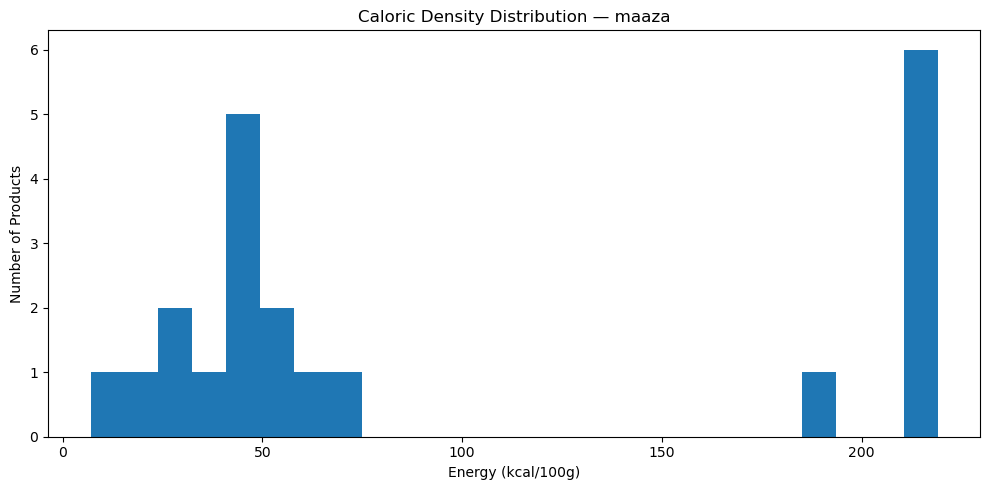


Observation: Energy content ranges from 7.0 to 219.0 kcal/100g, with a median of 50.0 kcal/100g. The middle 50% of products fall between 44.0 and 214.0 kcal/100g. The higher mean relative to the median suggests that a smaller number of high-calorie products increase the overall average.


In [14]:
plot_calorie_distribution(
    df,
    brand_name
)

##### Nutri-Score Rating

In [15]:
def plot_nutriscore(
    df,
    brand_name,
    column="nutriscore_grade"
):

    if column not in df.columns:

        print(
            "Nutri-Score column not available."
        )

        return

    scores = (
        df[column]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    scores = scores.replace(
        {
            "not-applicable": "n/a",
            "nan": "unknown",
            "": "unknown"
        }
    )

    counts = scores.value_counts()

    preferred_order = [
        "a",
        "b",
        "c",
        "d",
        "e",
        "unknown",
        "n/a"
    ]

    order = [
        x for x in preferred_order
        if x in counts.index
    ]

    counts = counts[order]

    # Plot

    plt.figure(figsize=(9, 5))

    counts.plot(
        kind="bar"
    )

    plt.title(
        f"Nutri-Score Distribution — {brand_name}"
    )

    plt.xlabel("Nutri-Score")
    plt.ylabel("Number of Products")

    plt.xticks(
        range(len(order)),
        [
            x.upper()
            if len(x) == 1
            else x.title()
            for x in order
        ],
        rotation=0
    )

    plt.tight_layout()
    plt.show()

    # Automatic observation

    valid_scores = scores[
        scores.isin(["a", "b", "c", "d", "e"])
    ]

    valid_percentage = (
        len(valid_scores)
        / len(scores)
        * 100
    )

    unknown_percentage = (
        len(scores[
            scores.isin(["unknown", "n/a"])
        ])
        / len(scores)
        * 100
    )

    if not valid_scores.empty:

        dominant_score = (
            valid_scores
            .value_counts()
            .idxmax()
            .upper()
        )

        observation = (
            f"Observation: Nutri-Score data is available for "
            f"{valid_percentage:.1f}% of the products."
        )

        observation += (
            f" Among products with a valid score, "
            f"Grade {dominant_score} is the most common category."
        )

    else:

        observation = (
            "Observation: No valid Nutri-Score grades are available "
            "for the dataset."
        )

    if unknown_percentage > 20:

        observation += (
            f" However, {unknown_percentage:.1f}% of records are "
            "unknown or not applicable, which limits the completeness "
            "of nutritional comparisons."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

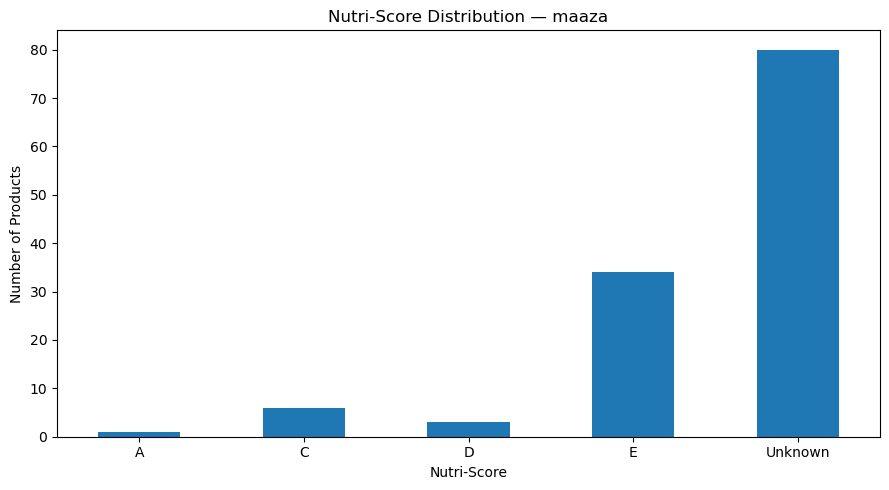


Observation: Nutri-Score data is available for 35.5% of the products. Among products with a valid score, Grade E is the most common category. However, 64.5% of records are unknown or not applicable, which limits the completeness of nutritional comparisons.


In [16]:
plot_nutriscore(
    df,
    brand_name
)

#### 1.3 Formulation & Processing

##### NOVA Processing Level

In [17]:
def plot_nova(
    df,
    brand_name,
    column="nova_group"
):

    if column not in df.columns:

        print(
            "NOVA group column not available."
        )

        return

    nova = pd.to_numeric(
        df[column],
        errors="coerce"
    ).dropna()

    if nova.empty:

        print(
            "No valid NOVA data available."
        )

        return

    nova = nova.astype(int)

    nova = nova.map(
        {
            1: "Group 1",
            2: "Group 2",
            3: "Group 3",
            4: "Group 4"
        }
    )

    counts = (
        nova
        .value_counts()
        .reindex(
            [
                "Group 1",
                "Group 2",
                "Group 3",
                "Group 4"
            ],
            fill_value=0
        )
    )

    # Plot

    plt.figure(figsize=(8, 5))

    counts.plot(
        kind="bar"
    )

    plt.title(
        f"NOVA Processing Level — {brand_name}"
    )

    plt.xlabel("NOVA Group")
    plt.ylabel("Number of Products")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # Automatic observation

    dominant_group = counts.idxmax()

    dominant_count = counts.max()

    dominant_percentage = (
        dominant_count
        / counts.sum()
        * 100
    )

    observation = (
        f"Observation: {dominant_group} is the dominant processing "
        f"category, representing {dominant_percentage:.1f}% "
        f"of products with available NOVA information."
    )

    if dominant_group == "Group 4":

        observation += (
            " This indicates that the majority of classified products "
            "are categorized as ultra-processed."
        )

    elif dominant_group == "Group 1":

        observation += (
            " This indicates that the majority of classified products "
            "are minimally processed or unprocessed."
        )

    else:

        observation += (
            " This indicates that the portfolio is concentrated "
            "within an intermediate level of food processing."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

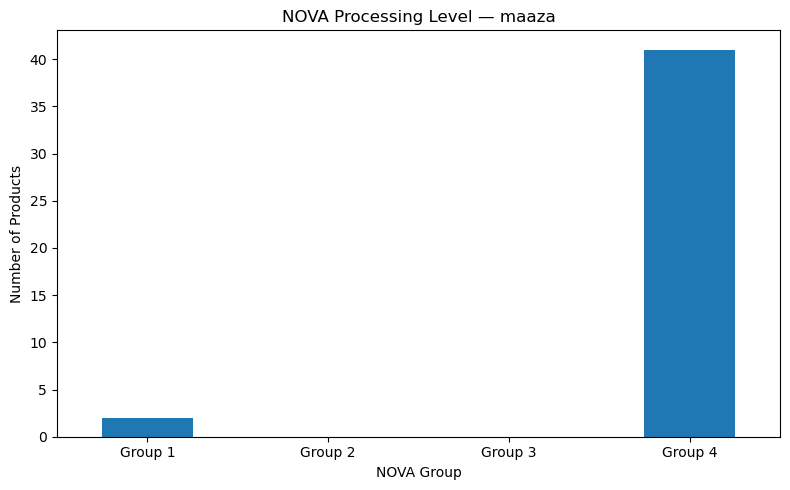


Observation: Group 4 is the dominant processing category, representing 95.3% of products with available NOVA information. This indicates that the majority of classified products are categorized as ultra-processed.


In [18]:
plot_nova(
    df,
    brand_name
)

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

In [19]:

def plot_packaging(
    pack_df,
    brand_name,
    column="packaging_tags",
    top_n=10
):

    if pack_df.empty:

        print(
            "Packaging data is not available."
        )

        return

    counts = (
        pack_df[column]
        .fillna("unknown")
        .value_counts()
        .head(top_n)
    )

    # Plot

    plt.figure(figsize=(10, 6))

    counts.sort_values().plot(
        kind="barh"
    )

    plt.title(
        f"Top {top_n} Packaging Types — {brand_name}"
    )

    plt.xlabel("Number of Records")
    plt.ylabel("Packaging Type")

    plt.tight_layout()
    plt.show()

    # Automatic observation

    dominant = counts.index[0]
    dominant_count = counts.iloc[0]

    observation = (
        f"Observation: '{dominant}' is the most frequently recorded "
        f"packaging category with {dominant_count:,} entries."
    )

    if dominant == "unknown":

        identifiable = (
            counts[
                counts.index != "unknown"
            ]
        )

        if not identifiable.empty:

            top_material = identifiable.index[0]
            top_material_count = identifiable.iloc[0]

            observation += (
                f" Among identifiable packaging categories, "
                f"'{top_material}' is the most common with "
                f"{top_material_count:,} entries."
            )

        observation += (
            " The dominance of unknown records indicates substantial "
            "missingness in the packaging data, so conclusions about "
            "the complete packaging composition should be interpreted "
            "with caution."
        )

    else:

        observation += (
            " This suggests that the portfolio has a strong "
            "representation of this packaging category among "
            "the available records."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

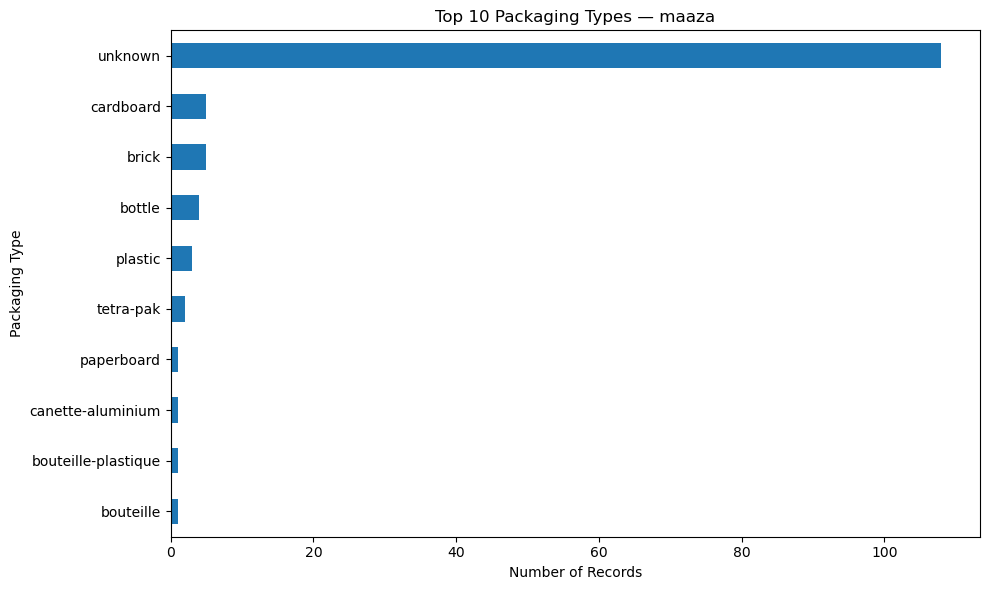


Observation: 'unknown' is the most frequently recorded packaging category with 108 entries. Among identifiable packaging categories, 'brick' is the most common with 5 entries. The dominance of unknown records indicates substantial missingness in the packaging data, so conclusions about the complete packaging composition should be interpreted with caution.


In [20]:
plot_packaging(
    pack_df,
    brand_name
)

##### Environmental Data Transparency (Eco-Score)

In [21]:
def plot_ecoscore(
    df,
    brand_name,
    column="ecoscore_grade"
):

    if column not in df.columns:

        print(
            "Eco-Score column not available."
        )

        return

    eco = (
        df[column]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    eco = eco.replace(
        {
            "nan": "unknown",
            "": "unknown"
        }
    )

    eco_status = eco.apply(
        lambda x:
        "Available"
        if x in ["a", "b", "c", "d", "e"]
        else "Unknown / Unavailable"
    )

    counts = (
        eco_status
        .value_counts()
    )

    # Plot

    plt.figure(figsize=(7, 5))

    counts.plot(
        kind="bar"
    )

    plt.title(
        f"Eco-Score Data Availability — {brand_name}"
    )

    plt.xlabel("Eco-Score Status")
    plt.ylabel("Number of Products")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # Automatic observation

    total = counts.sum()

    available = counts.get(
        "Available",
        0
    )

    unavailable = counts.get(
        "Unknown / Unavailable",
        0
    )

    available_percentage = (
        available / total * 100
    )

    unavailable_percentage = (
        unavailable / total * 100
    )

    observation = (
        f"Observation: Eco-Score information is available for "
        f"{available_percentage:.1f}% of the products, while "
        f"{unavailable_percentage:.1f}% have unknown or unavailable "
        f"Eco-Score information."
    )

    if unavailable_percentage > 50:

        observation += (
            " This means the visualization primarily reflects "
            "environmental data availability rather than providing "
            "a complete assessment of environmental performance."
        )

    else:

        observation += (
            " The available data provides a reasonable basis for "
            "comparing environmental score coverage within the portfolio."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

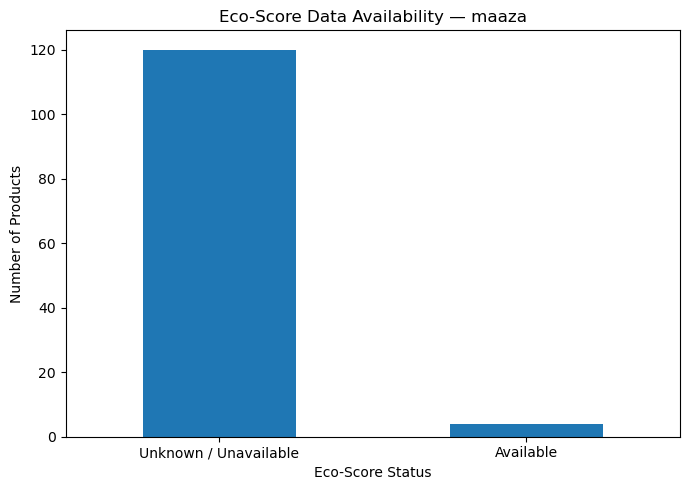


Observation: Eco-Score information is available for 3.2% of the products, while 96.8% have unknown or unavailable Eco-Score information. This means the visualization primarily reflects environmental data availability rather than providing a complete assessment of environmental performance.


In [22]:
plot_ecoscore(
    df,
    brand_name
)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

In [23]:
def plot_portfolio_distribution(
    country_df,
    brand_name,
    product_col="code",
    country_col="countries_tags"
):

    if country_df.empty:
        print("Country data is not available.")
        return

    # Number of markets per product
    product_markets = (
        country_df
        .groupby(product_col)[country_col]
        .nunique()
    )

    # Classification
    portfolio_type = product_markets.apply(
        lambda x:
        "Localized"
        if x == 1
        else "Multi-Market"
    )

    portfolio_counts = (
        portfolio_type
        .value_counts()
    )

    total = portfolio_counts.sum()

    percentages = (
        portfolio_counts / total * 100
    )

    # Plot
    plt.figure(figsize=(7, 5))

    portfolio_counts.plot(
        kind="bar"
    )

    plt.title(
        f"Localized vs Multi-Market Products — {brand_name}"
    )

    plt.xlabel("Portfolio Type")
    plt.ylabel("Number of Unique Products")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # Automatic observation

    dominant = portfolio_counts.idxmax()
    dominant_count = portfolio_counts.max()
    dominant_percentage = percentages[dominant]

    observation = (
        f"Observation: {dominant} products represent the larger "
        f"segment of the portfolio, accounting for "
        f"{dominant_percentage:.1f}% ({dominant_count:,} products)."
    )

    if dominant == "Localized":

        observation += (
            " This suggests that the dataset contains a stronger "
            "presence of products associated with individual markets, "
            "indicating localized portfolio representation."
        )

    else:

        observation += (
            " This suggests that a substantial portion of products "
            "are associated with multiple markets, indicating "
            "broader international distribution."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

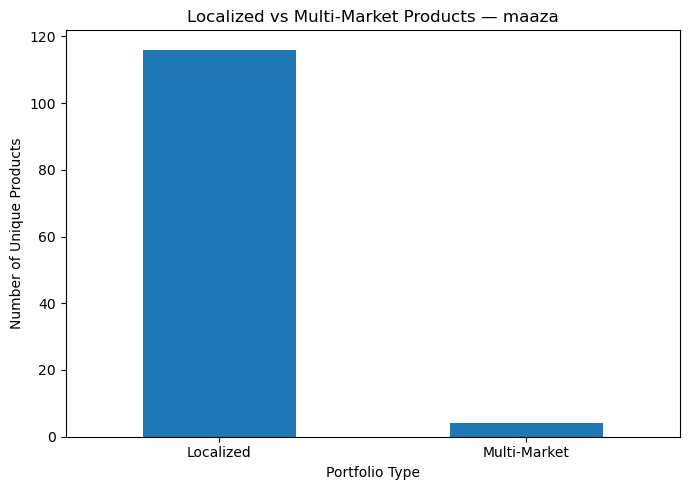


Observation: Localized products represent the larger segment of the portfolio, accounting for 96.7% (116 products). This suggests that the dataset contains a stronger presence of products associated with individual markets, indicating localized portfolio representation.


In [24]:
plot_portfolio_distribution(
    country_df=country_df,
    brand_name=brand_name
)

### Brand: Minute-Maid

In [25]:
brand_name = "Minutemaid"

df, country_df, pack_df = prepare_brand_data(
    minutemaid
)

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

In [26]:
def plot_top_markets(
    country_df,
    brand_name,
    product_col="code",
    country_col="countries_tags",
    top_n=10
):

    if country_df.empty:
        print("Country data is not available.")
        return

    if product_col not in country_df.columns:
        print(f"Column '{product_col}' not found.")
        return

    # Count unique products
    country_counts = (
        country_df
        .groupby(country_col)[product_col]
        .nunique()
        .sort_values(ascending=False)
        .head(top_n)
    )

    # Plot
    plt.figure(figsize=(10, 6))

    country_counts.sort_values().plot(
        kind="barh"
    )

    plt.title(
        f"Top {top_n} Markets by Product Representation — {brand_name}"
    )

    plt.xlabel("Number of Unique Products")
    plt.ylabel("Country")

    plt.tight_layout()
    plt.show()

    # -------------------------
    # Automatic Observation
    # -------------------------

    top_country = country_counts.index[0]
    top_value = country_counts.iloc[0]

    observation = (
        f"Observation: {top_country.title()} has the highest "
        f"product representation with {top_value:,} unique products."
    )

    if len(country_counts) >= 3:

        second_country = country_counts.index[1]
        second_value = country_counts.iloc[1]

        third_country = country_counts.index[2]
        third_value = country_counts.iloc[2]

        observation += (
            f" It is followed by {second_country.title()} "
            f"with {second_value:,} products and "
            f"{third_country.title()} with {third_value:,} products."
        )

    observation += (
        " This indicates that the dataset is geographically "
        "concentrated in a limited number of major markets."
    )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

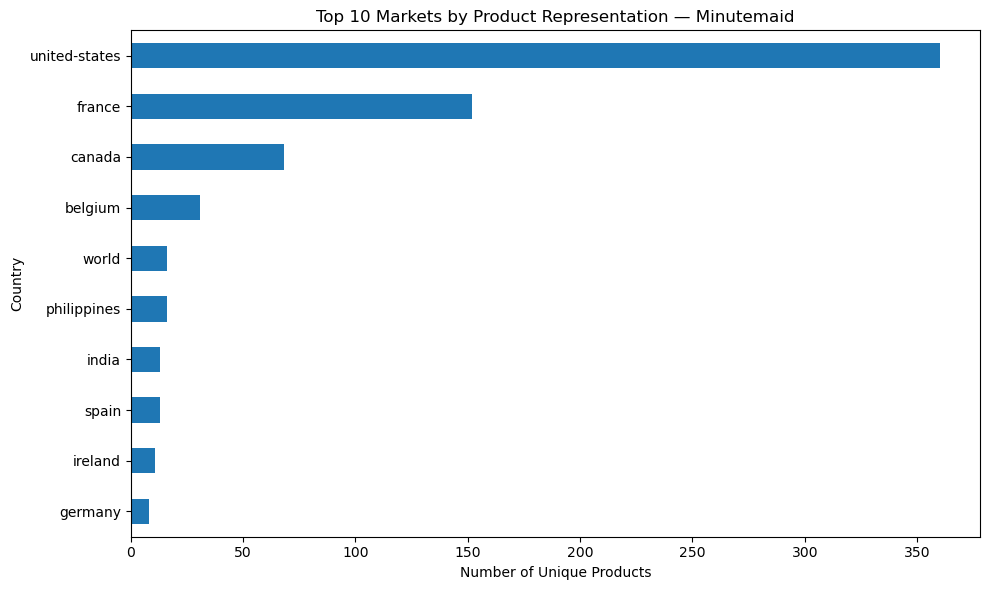


Observation: United-States has the highest product representation with 360 unique products. It is followed by France with 152 products and Canada with 68 products. This indicates that the dataset is geographically concentrated in a limited number of major markets.


In [27]:
plot_top_markets(
    country_df,
    brand_name
)

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

In [28]:
def plot_market_density(
    country_df,
    brand_name,
    product_col="code",
    country_col="countries_tags",
    top_n=8
):

    if country_df.empty:
        print("Country data is not available.")
        return

    market_counts = (
        country_df
        .groupby(country_col)[product_col]
        .nunique()
        .sort_values(ascending=False)
        .head(top_n)
    )

    total = market_counts.sum()

    market_percentage = (
        market_counts / total * 100
    )

    # Plot
    plt.figure(figsize=(8, 8))

    plt.pie(
        market_counts,
        labels=[
            country.title()
            for country in market_counts.index
        ],
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops={"width": 0.45}
    )

    plt.title(
        f"Market Density Distribution — {brand_name}"
    )

    plt.tight_layout()
    plt.show()

    # Automatic observation

    top_market = market_counts.index[0]
    top_percentage = market_percentage.iloc[0]

    top_three_percentage = (
        market_percentage
        .head(3)
        .sum()
    )

    observation = (
        f"Observation: {top_market.title()} represents the "
        f"largest share of products among the top {top_n} markets "
        f"at {top_percentage:.1f}%."
    )

    observation += (
        f" The top three markets together account for "
        f"{top_three_percentage:.1f}% of the products represented "
        f"in this visualization, indicating that the portfolio "
        f"is concentrated in a relatively small number of markets."
    )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)


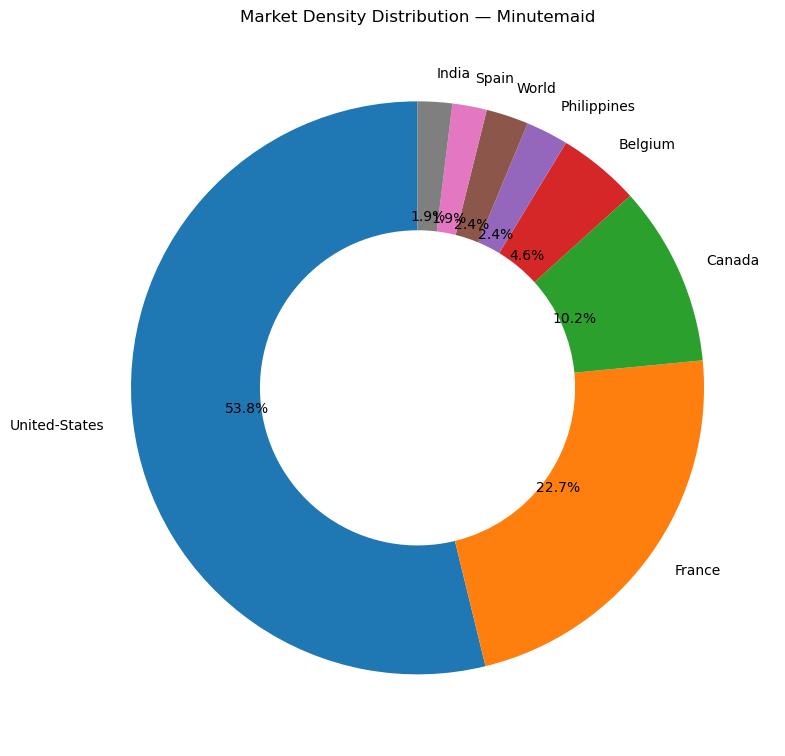


Observation: United-States represents the largest share of products among the top 8 markets at 53.8%. The top three markets together account for 86.7% of the products represented in this visualization, indicating that the portfolio is concentrated in a relatively small number of markets.


In [29]:
plot_market_density(
    country_df,
    brand_name
)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

In [30]:
def plot_portfolio_distribution(
    country_df,
    brand_name,
    product_col="code",
    country_col="countries_tags"
):

    if country_df.empty:
        print("Country data is not available.")
        return

    # Number of markets per product
    product_markets = (
        country_df
        .groupby(product_col)[country_col]
        .nunique()
    )

    # Classification
    portfolio_type = product_markets.apply(
        lambda x:
        "Localized"
        if x == 1
        else "Multi-Market"
    )

    portfolio_counts = (
        portfolio_type
        .value_counts()
    )

    total = portfolio_counts.sum()

    percentages = (
        portfolio_counts / total * 100
    )

    # Plot
    plt.figure(figsize=(7, 5))

    portfolio_counts.plot(
        kind="bar"
    )

    plt.title(
        f"Localized vs Multi-Market Products — {brand_name}"
    )

    plt.xlabel("Portfolio Type")
    plt.ylabel("Number of Unique Products")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # Automatic observation

    dominant = portfolio_counts.idxmax()
    dominant_count = portfolio_counts.max()
    dominant_percentage = percentages[dominant]

    observation = (
        f"Observation: {dominant} products represent the larger "
        f"segment of the portfolio, accounting for "
        f"{dominant_percentage:.1f}% ({dominant_count:,} products)."
    )

    if dominant == "Localized":

        observation += (
            " This suggests that the dataset contains a stronger "
            "presence of products associated with individual markets, "
            "indicating localized portfolio representation."
        )

    else:

        observation += (
            " This suggests that a substantial portion of products "
            "are associated with multiple markets, indicating "
            "broader international distribution."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

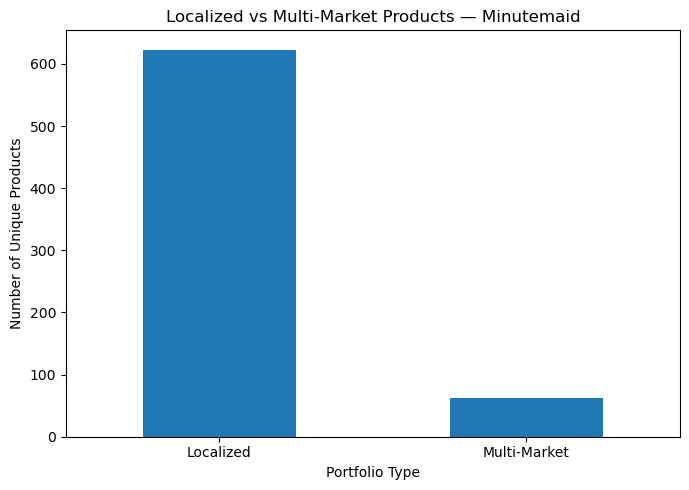


Observation: Localized products represent the larger segment of the portfolio, accounting for 90.9% (623 products). This suggests that the dataset contains a stronger presence of products associated with individual markets, indicating localized portfolio representation.


In [31]:
plot_portfolio_distribution(
    country_df,
    brand_name
)

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

In [32]:
def plot_sugar_distribution(
    df,
    brand_name,
    sugar_col="nutriments.sugars_100g"
):

    if sugar_col not in df.columns:

        print(
            f"Sugar column '{sugar_col}' not found."
        )

        return

    sugar = pd.to_numeric(
        df[sugar_col],
        errors="coerce"
    ).dropna()

    if sugar.empty:

        print("No valid sugar data available.")
        return

    # Plot

    plt.figure(figsize=(10, 5))

    plt.hist(
        sugar,
        bins=25
    )

    plt.title(
        f"Sugar Content Distribution — {brand_name}"
    )

    plt.xlabel("Sugar (g/100g)")
    plt.ylabel("Number of Products")

    plt.tight_layout()
    plt.show()

    # Statistics

    median = sugar.median()
    mean = sugar.mean()
    minimum = sugar.min()
    maximum = sugar.max()

    q1 = sugar.quantile(0.25)
    q3 = sugar.quantile(0.75)

    observation = (
        f"Observation: Sugar content ranges from "
        f"{minimum:.1f} to {maximum:.1f} g/100g, "
        f"with a median of {median:.1f} g/100g."
    )

    observation += (
        f" The middle 50% of products fall between "
        f"{q1:.1f} and {q3:.1f} g/100g."
    )

    # Detect skew

    if mean > median * 1.2:

        observation += (
            " The mean is noticeably higher than the median, "
            "suggesting that a smaller number of high-sugar products "
            "are pulling the overall average upward."
        )

    elif median > mean * 1.2:

        observation += (
            " The median is noticeably higher than the mean, "
            "indicating that lower-value products may be influencing "
            "the overall average."
        )

    else:

        observation += (
            " The mean and median are relatively close, suggesting "
            "that the overall distribution is not strongly skewed."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

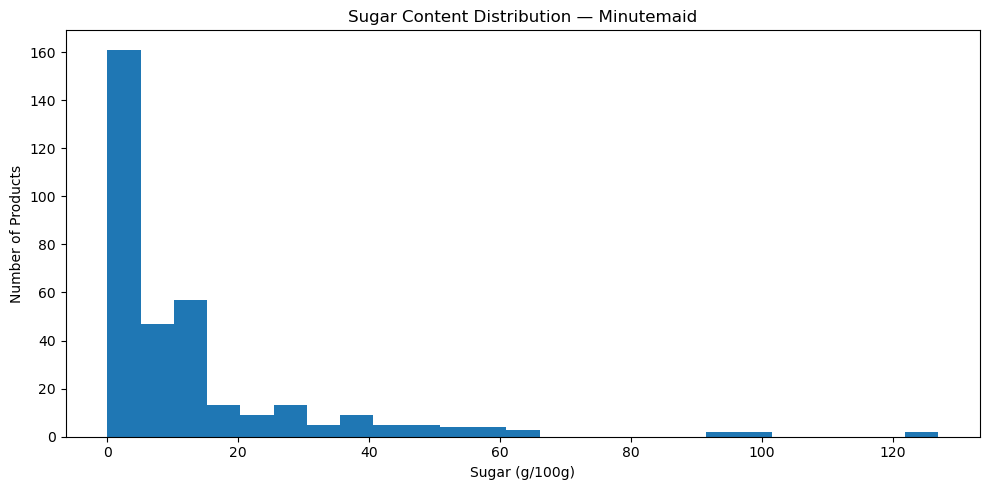


Observation: Sugar content ranges from 0.0 to 127.0 g/100g, with a median of 7.9 g/100g. The middle 50% of products fall between 1.0 and 12.3 g/100g. The mean is noticeably higher than the median, suggesting that a smaller number of high-sugar products are pulling the overall average upward.


In [33]:
plot_sugar_distribution(
    df,
    brand_name
)

##### Caloric Density

In [34]:
def plot_calorie_distribution(
    df,
    brand_name,
    calorie_col="nutriments.energy-kcal_100g"
):

    if calorie_col not in df.columns:

        print(
            f"Calorie column '{calorie_col}' not found."
        )

        return

    calories = pd.to_numeric(
        df[calorie_col],
        errors="coerce"
    ).dropna()

    if calories.empty:

        print("No valid calorie data available.")
        return

    # Plot

    plt.figure(figsize=(10, 5))

    plt.hist(
        calories,
        bins=25
    )

    plt.title(
        f"Caloric Density Distribution — {brand_name}"
    )

    plt.xlabel("Energy (kcal/100g)")
    plt.ylabel("Number of Products")

    plt.tight_layout()
    plt.show()

    # Statistics

    median = calories.median()
    mean = calories.mean()

    minimum = calories.min()
    maximum = calories.max()

    q1 = calories.quantile(0.25)
    q3 = calories.quantile(0.75)

    observation = (
        f"Observation: Energy content ranges from "
        f"{minimum:.1f} to {maximum:.1f} kcal/100g, "
        f"with a median of {median:.1f} kcal/100g."
    )

    observation += (
        f" The middle 50% of products fall between "
        f"{q1:.1f} and {q3:.1f} kcal/100g."
    )

    if mean > median * 1.2:

        observation += (
            " The higher mean relative to the median suggests "
            "that a smaller number of high-calorie products "
            "increase the overall average."
        )

    else:

        observation += (
            " The mean and median are relatively close, indicating "
            "a more balanced distribution of caloric density."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

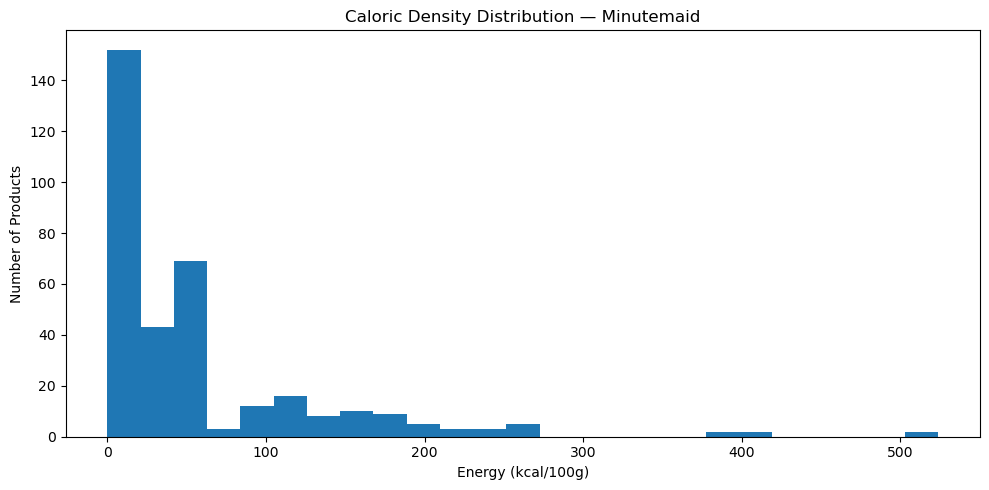


Observation: Energy content ranges from 0.0 to 524.0 kcal/100g, with a median of 33.6 kcal/100g. The middle 50% of products fall between 5.5 and 52.4 kcal/100g. The higher mean relative to the median suggests that a smaller number of high-calorie products increase the overall average.


In [35]:
plot_calorie_distribution(
    df,
    brand_name
)

##### Nutri-Score Rating

In [36]:
def plot_nutriscore(
    df,
    brand_name,
    column="nutriscore_grade"
):

    if column not in df.columns:

        print(
            "Nutri-Score column not available."
        )

        return

    scores = (
        df[column]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    scores = scores.replace(
        {
            "not-applicable": "n/a",
            "nan": "unknown",
            "": "unknown"
        }
    )

    counts = scores.value_counts()

    preferred_order = [
        "a",
        "b",
        "c",
        "d",
        "e",
        "unknown",
        "n/a"
    ]

    order = [
        x for x in preferred_order
        if x in counts.index
    ]

    counts = counts[order]

    # Plot

    plt.figure(figsize=(9, 5))

    counts.plot(
        kind="bar"
    )

    plt.title(
        f"Nutri-Score Distribution — {brand_name}"
    )

    plt.xlabel("Nutri-Score")
    plt.ylabel("Number of Products")

    plt.xticks(
        range(len(order)),
        [
            x.upper()
            if len(x) == 1
            else x.title()
            for x in order
        ],
        rotation=0
    )

    plt.tight_layout()
    plt.show()

    # Automatic observation

    valid_scores = scores[
        scores.isin(["a", "b", "c", "d", "e"])
    ]

    valid_percentage = (
        len(valid_scores)
        / len(scores)
        * 100
    )

    unknown_percentage = (
        len(scores[
            scores.isin(["unknown", "n/a"])
        ])
        / len(scores)
        * 100
    )

    if not valid_scores.empty:

        dominant_score = (
            valid_scores
            .value_counts()
            .idxmax()
            .upper()
        )

        observation = (
            f"Observation: Nutri-Score data is available for "
            f"{valid_percentage:.1f}% of the products."
        )

        observation += (
            f" Among products with a valid score, "
            f"Grade {dominant_score} is the most common category."
        )

    else:

        observation = (
            "Observation: No valid Nutri-Score grades are available "
            "for the dataset."
        )

    if unknown_percentage > 20:

        observation += (
            f" However, {unknown_percentage:.1f}% of records are "
            "unknown or not applicable, which limits the completeness "
            "of nutritional comparisons."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

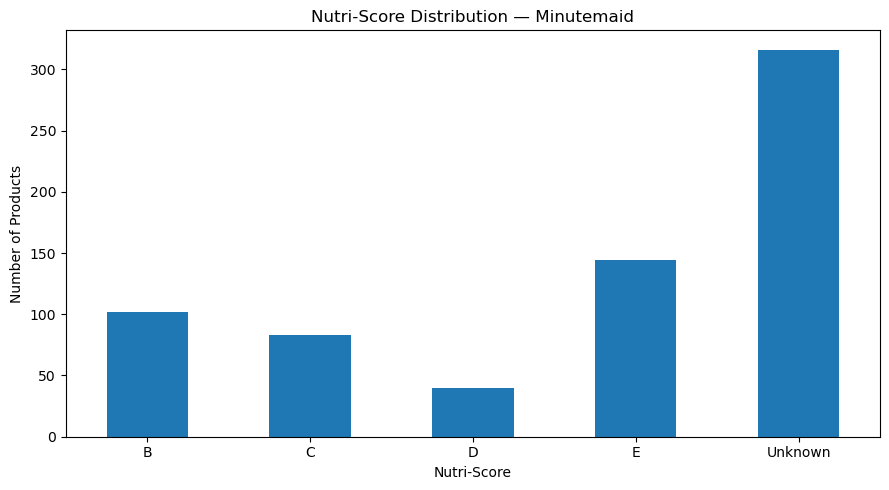


Observation: Nutri-Score data is available for 53.9% of the products. Among products with a valid score, Grade E is the most common category. However, 46.1% of records are unknown or not applicable, which limits the completeness of nutritional comparisons.


In [37]:
plot_nutriscore(
    df,
    brand_name
)

#### 1.3 Formulation & Processing

##### NOVA Processing Level

In [38]:
def plot_nova(
    df,
    brand_name,
    column="nova_group"
):

    if column not in df.columns:

        print(
            "NOVA group column not available."
        )

        return

    nova = pd.to_numeric(
        df[column],
        errors="coerce"
    ).dropna()

    if nova.empty:

        print(
            "No valid NOVA data available."
        )

        return

    nova = nova.astype(int)

    nova = nova.map(
        {
            1: "Group 1",
            2: "Group 2",
            3: "Group 3",
            4: "Group 4"
        }
    )

    counts = (
        nova
        .value_counts()
        .reindex(
            [
                "Group 1",
                "Group 2",
                "Group 3",
                "Group 4"
            ],
            fill_value=0
        )
    )

    # Plot

    plt.figure(figsize=(8, 5))

    counts.plot(
        kind="bar"
    )

    plt.title(
        f"NOVA Processing Level — {brand_name}"
    )

    plt.xlabel("NOVA Group")
    plt.ylabel("Number of Products")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # Automatic observation

    dominant_group = counts.idxmax()

    dominant_count = counts.max()

    dominant_percentage = (
        dominant_count
        / counts.sum()
        * 100
    )

    observation = (
        f"Observation: {dominant_group} is the dominant processing "
        f"category, representing {dominant_percentage:.1f}% "
        f"of products with available NOVA information."
    )

    if dominant_group == "Group 4":

        observation += (
            " This indicates that the majority of classified products "
            "are categorized as ultra-processed."
        )

    elif dominant_group == "Group 1":

        observation += (
            " This indicates that the majority of classified products "
            "are minimally processed or unprocessed."
        )

    else:

        observation += (
            " This indicates that the portfolio is concentrated "
            "within an intermediate level of food processing."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

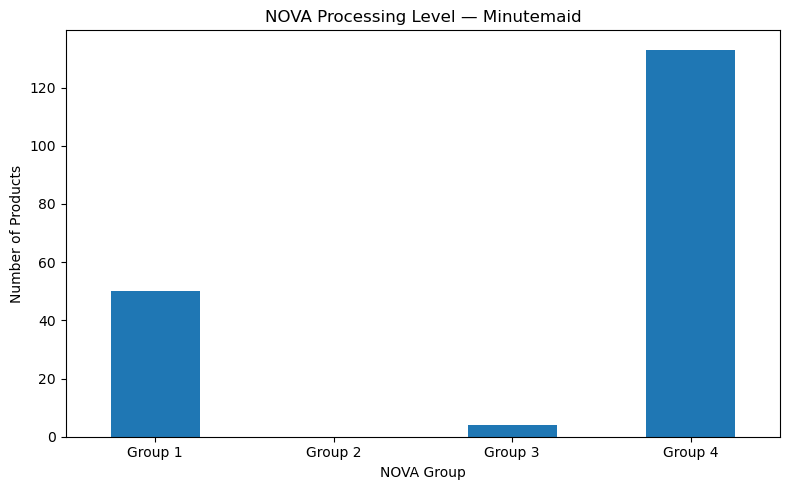


Observation: Group 4 is the dominant processing category, representing 71.1% of products with available NOVA information. This indicates that the majority of classified products are categorized as ultra-processed.


In [39]:
plot_nova(
    df,
    brand_name
)

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

In [40]:
def plot_packaging(
    pack_df,
    brand_name,
    column="packaging_tags",
    top_n=10
):

    if pack_df.empty:

        print(
            "Packaging data is not available."
        )

        return

    counts = (
        pack_df[column]
        .fillna("unknown")
        .value_counts()
        .head(top_n)
    )

    # Plot

    plt.figure(figsize=(10, 6))

    counts.sort_values().plot(
        kind="barh"
    )

    plt.title(
        f"Top {top_n} Packaging Types — {brand_name}"
    )

    plt.xlabel("Number of Records")
    plt.ylabel("Packaging Type")

    plt.tight_layout()
    plt.show()

    # Automatic observation

    dominant = counts.index[0]
    dominant_count = counts.iloc[0]

    observation = (
        f"Observation: '{dominant}' is the most frequently recorded "
        f"packaging category with {dominant_count:,} entries."
    )

    if dominant == "unknown":

        identifiable = (
            counts[
                counts.index != "unknown"
            ]
        )

        if not identifiable.empty:

            top_material = identifiable.index[0]
            top_material_count = identifiable.iloc[0]

            observation += (
                f" Among identifiable packaging categories, "
                f"'{top_material}' is the most common with "
                f"{top_material_count:,} entries."
            )

        observation += (
            " The dominance of unknown records indicates substantial "
            "missingness in the packaging data, so conclusions about "
            "the complete packaging composition should be interpreted "
            "with caution."
        )

    else:

        observation += (
            " This suggests that the portfolio has a strong "
            "representation of this packaging category among "
            "the available records."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

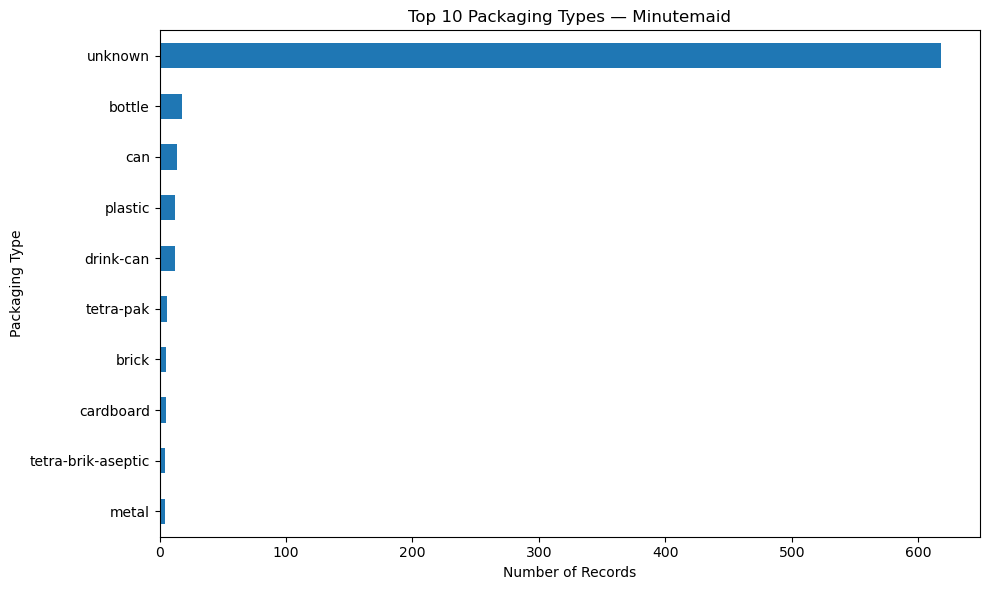


Observation: 'unknown' is the most frequently recorded packaging category with 618 entries. Among identifiable packaging categories, 'bottle' is the most common with 18 entries. The dominance of unknown records indicates substantial missingness in the packaging data, so conclusions about the complete packaging composition should be interpreted with caution.


In [41]:
plot_packaging(
    pack_df,
    brand_name
)

##### Environmental Data Transparency (Eco-Score)

In [42]:

def plot_ecoscore(
    df,
    brand_name,
    column="ecoscore_grade"
):

    if column not in df.columns:

        print(
            "Eco-Score column not available."
        )

        return

    eco = (
        df[column]
        .fillna("unknown")
        .astype(str)
        .str.strip()
        .str.lower()
    )

    eco = eco.replace(
        {
            "nan": "unknown",
            "": "unknown"
        }
    )

    eco_status = eco.apply(
        lambda x:
        "Available"
        if x in ["a", "b", "c", "d", "e"]
        else "Unknown / Unavailable"
    )

    counts = (
        eco_status
        .value_counts()
    )

    # Plot

    plt.figure(figsize=(7, 5))

    counts.plot(
        kind="bar"
    )

    plt.title(
        f"Eco-Score Data Availability — {brand_name}"
    )

    plt.xlabel("Eco-Score Status")
    plt.ylabel("Number of Products")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # Automatic observation

    total = counts.sum()

    available = counts.get(
        "Available",
        0
    )

    unavailable = counts.get(
        "Unknown / Unavailable",
        0
    )

    available_percentage = (
        available / total * 100
    )

    unavailable_percentage = (
        unavailable / total * 100
    )

    observation = (
        f"Observation: Eco-Score information is available for "
        f"{available_percentage:.1f}% of the products, while "
        f"{unavailable_percentage:.1f}% have unknown or unavailable "
        f"Eco-Score information."
    )

    if unavailable_percentage > 50:

        observation += (
            " This means the visualization primarily reflects "
            "environmental data availability rather than providing "
            "a complete assessment of environmental performance."
        )

    else:

        observation += (
            " The available data provides a reasonable basis for "
            "comparing environmental score coverage within the portfolio."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

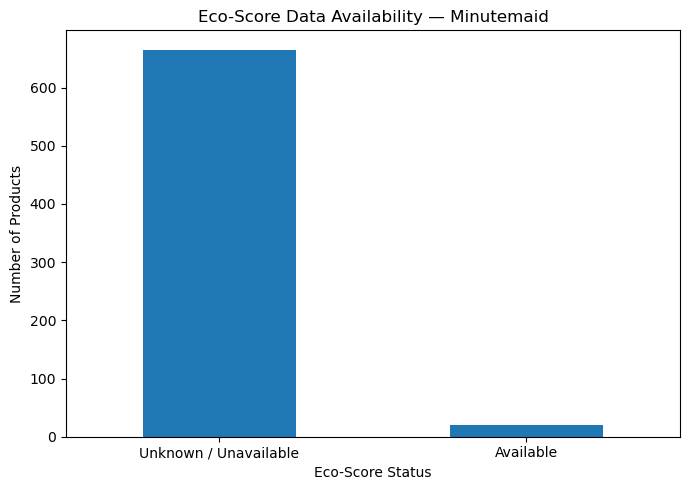


Observation: Eco-Score information is available for 2.9% of the products, while 97.1% have unknown or unavailable Eco-Score information. This means the visualization primarily reflects environmental data availability rather than providing a complete assessment of environmental performance.


In [43]:
plot_ecoscore(
    df,
    brand_name
)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

In [44]:
def plot_portfolio_distribution(
    country_df,
    brand_name,
    product_col="code",
    country_col="countries_tags"
):

    if country_df.empty:
        print("Country data is not available.")
        return

    # Number of markets per product
    product_markets = (
        country_df
        .groupby(product_col)[country_col]
        .nunique()
    )

    # Classification
    portfolio_type = product_markets.apply(
        lambda x:
        "Localized"
        if x == 1
        else "Multi-Market"
    )

    portfolio_counts = (
        portfolio_type
        .value_counts()
    )

    total = portfolio_counts.sum()

    percentages = (
        portfolio_counts / total * 100
    )

    # Plot
    plt.figure(figsize=(7, 5))

    portfolio_counts.plot(
        kind="bar"
    )

    plt.title(
        f"Localized vs Multi-Market Products — {brand_name}"
    )

    plt.xlabel("Portfolio Type")
    plt.ylabel("Number of Unique Products")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

    # Automatic observation

    dominant = portfolio_counts.idxmax()
    dominant_count = portfolio_counts.max()
    dominant_percentage = percentages[dominant]

    observation = (
        f"Observation: {dominant} products represent the larger "
        f"segment of the portfolio, accounting for "
        f"{dominant_percentage:.1f}% ({dominant_count:,} products)."
    )

    if dominant == "Localized":

        observation += (
            " This suggests that the dataset contains a stronger "
            "presence of products associated with individual markets, "
            "indicating localized portfolio representation."
        )

    else:

        observation += (
            " This suggests that a substantial portion of products "
            "are associated with multiple markets, indicating "
            "broader international distribution."
        )

    print("\n" + "=" * 80)
    print(observation)
    print("=" * 80)

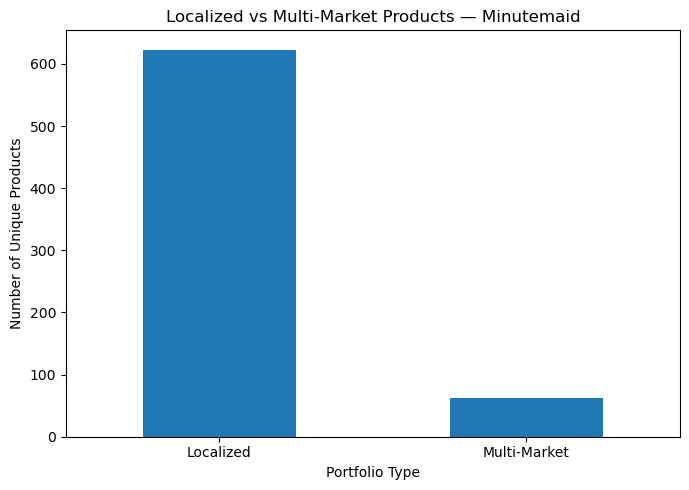


Observation: Localized products represent the larger segment of the portfolio, accounting for 90.9% (623 products). This suggests that the dataset contains a stronger presence of products associated with individual markets, indicating localized portfolio representation.


In [45]:
plot_portfolio_distribution(
    country_df=country_df,
    brand_name=brand_name
)

### Brand: Schweppes

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Sprite

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

### Brand: Topo Chico

#### 1.1 Geographic Footprint

##### Total Market Presence
Distribution across national markets.

##### Market Density Distribution
Breakdown of the catalog's top markets globally.

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

#### 1.2 Health & Nutrition

##### Sugar Profiling (Pre 100g)

##### Caloric Density

##### Nutri-Score Rating

#### 1.3 Formulation & Processing

##### NOVA Processing Level

#### 1.4 Packaging & Eco-Impact

##### Primary Packaging Substrates

##### Environmental Data Transparency (Eco-Score)

##### Portfolio Distribution Nature
Analysis of Localized Single-Market vs. Global Formulations.

## Section 2: Geographic Overview
Catalog Variations across Various Countries

### Brand: Coca-Cola

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Fairlife

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Fanta

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Maaza

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Minute Maid

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Schweppes

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Sprite

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

### Brand: Topo Chico

#### 2.1 Portfolio Depth & Category Mix by Nation

#### 2.2 Local Market Flavors & Product Specializations

## Section 3: Health & Nutrition Differences Across Regions

### Brand: Coca-Cola

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Fairlife

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Fanta

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Maaza

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Minute Maid

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Schweppes

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Sprite

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

### Brand: Topo Chico

#### 3.1 Regional Sugar Benchmarks

##### Cross-Border Sugar Variance

#### 3.2 Reformulation & Sweetener Shift

##### Regional Sweetening Analysis:

##### Nutri-Score Analysis

## Section 4: Formulation & Processing Across Regions

### Brand: Coca-Cola

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Fairlife

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Fanta

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Maaza

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Minute Maid

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Schweppes

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Sprite

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

### Brand: Topo Chico

#### 4.1 NOVA Group Variations by Market

#### 4.2 Ingredient & Additive Discrepancies

## Section 5: Packaging Preferences Across Regions

### Brand: Coca-Cola

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Fairlife

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Fanta

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Maaza

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Minute Maid

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Schweppes

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Sprite

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

### Brand: Topo Chico

#### 5.1 Material Preferences by Territory

#### 5.2 Regional Sustainability & Reporting Discrepancies

## Section 6: Limitations, Methodology & Strategic Conclusions